# Analyse: Sprachkomplexität der AfD im Bundestag

**Forschungsfrage:** Nutzen AfD-Abgeordnete komplexere Sprache (gemessen als LLM-*Surprisal*) als andere Fraktionen — entgegen der populistischen „Einfachheits"-These?

Jeder Block schreibt überprüfbare Outputs nach `analysis/output/{tables,figures}` und `analysis/logs`.

| Block | Inhalt |
|-------|--------|
| **A** | Setup: Seed, Pfade, Hilfsfunktionen |
| **B** | Datenaufbereitung |
| **C** | Explorative Datenanalyse (Deskriptives, Verteilungen, ICC, Konfundierung) |
| **D** | **Hauptmodell** H1 (M0/M1/M2/M2b) |
| **E** | **Explorative** Erweiterungen (Zeit, Opposition, Bildung, Gradient) |
| **F** | Robustheit (Maßvergleich, Längen-Sensitivität, Cluster-SE, Diagnostik) |
| **G** | Ergebnissicherung |



## Die nächsten zwei Zellen müssen nur ausgeführt werden, wenn die **Datengenerierungspipeline** neu ausgeführt wurde

In [1]:
# import pandas as pd
# from pathlib import Path
# from enrich_politicians import enrich

# DATA_DIR = Path("/Users/nickschlitter/Documents/forschungsarbeit/data_projektarbeit")

# for csv_path in sorted(DATA_DIR.glob("*_speeches_surprisal.csv")):
#     print(f"\n=== {csv_path.name} ===")
#     df = pd.read_csv(csv_path, index_col=0)
#     df["date"] = pd.to_datetime(df["date"])

#     enriched = enrich(df)

#     out_path = csv_path.with_name(csv_path.stem + "_enriched.csv")
#     enriched.to_csv(out_path, index=False)
#     print(f"Gespeichert → {out_path.name}")

In [2]:
# import pandas as pd
# from pathlib import Path
# from enrich_politicians import enrich

# DATA_DIR = Path("/Users/nickschlitter/Documents/forschungsarbeit/data_projektarbeit")

# def load_enriched(path):
#     df = pd.read_csv(path)
#     df["party"] = path.stem.split("_")[0].upper()
#     return df

# all_enriched = pd.concat(
#     [load_enriched(p) for p in sorted(DATA_DIR.glob("*_speeches_surprisal_enriched.csv"))],
#     ignore_index=True,
# )
# all_enriched["date"] = pd.to_datetime(all_enriched["date"])

# print(f"Reden gesamt : {len(all_enriched):,}")
# print(f"Parteien     : {sorted(all_enriched['party'].unique())}")
# print(f"Zeitraum     : {all_enriched['date'].min().date()} – {all_enriched['date'].max().date()}")

# all_enriched.to_csv(DATA_DIR / "all_speeches_enriched.csv", index=False)
# print(f"Gespeichert  → all_speeches_enriched.csv")

# display(all_enriched.head())

## **Block A**: Setup

In [ ]:
import re, json, time, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import patsy
import pyphen
from scipy.stats import chi2

SEED = 42
random.seed(SEED); np.random.seed(SEED)
warnings.filterwarnings("ignore")            # MixedLM-Konvergenzmeldungen
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight"})

# --- Pfade ---
DATA_FILE = Path("/Users/nickschlitter/Documents/forschungsarbeit/data_projektarbeit/all_speeches_enriched.csv")
ROOT = Path("/Users/nickschlitter/Documents/forschungsarbeit/analysis")
TAB, FIG, LOG, DAT = ROOT/"output"/"tables", ROOT/"output"/"figures", ROOT/"logs", ROOT/"data"
for d in (TAB, FIG, LOG, DAT):
    d.mkdir(parents=True, exist_ok=True)

PARTIES = ["CDU", "SPD", "GRUENE", "FDP", "DIELINKE", "AFD"]   # CDU = Referenzkategorie
RESULTS = {}   # gesammelte Kennzahlen für den finalen Text

all_enriched = pd.read_csv(DATA_FILE)

display(all_enriched.head())

# --- Hilfsfunktionen: Outputs speichern ---
def save_table(df, name, index=True):
    """Tabelle als .csv UND .md ablegen."""
    df.to_csv(TAB/f"{name}.csv", index=index)
    try:
        md = df.to_markdown(index=index, floatfmt=".3f")
    except Exception:
        md = df.to_string()
    (TAB/f"{name}.md").write_text(md)
    return df

def logline(msg, logfile="prep.log"):
    print(msg)
    with open(LOG/logfile, "a") as f:
        f.write(str(msg) + "\n")

# --- Hilfsfunktionen: Mixed-Effects-Modelle ---
def fit_lmm(formula, data, group="speaker_id", reml=True):
    """Linear Mixed Modell mit Random Intercept (lbfgs = robust)."""
    return smf.mixedlm(formula, data, groups=data[group]).fit(reml=reml, method="lbfgs")

def icc(result):
    """Intraklassenkorrelation aus Varianzkomponenten: g / (g + resid)."""
    g = float(result.cov_re.iloc[0, 0])
    r = float(result.scale)
    return g / (g + r), g, r

def pseudo_r2(result, data):
    """Nakagawa & Schielzeth (2013), Gauß-Approximation: (marginal, conditional)."""
    var_f = float(np.var(result.predict(data), ddof=1))   # Varianz der Fixed-Effects-Vorhersage
    var_a = float(result.cov_re.iloc[0, 0])               # Random-Intercept-Varianz
    var_e = float(result.scale)                           # Residualvarianz
    denom = var_f + var_a + var_e
    return var_f/denom, (var_f + var_a)/denom

def cohen_label(d):
    """Verbale Einordnung der Effektstärke nach Cohen (1988): 0.2 / 0.5 / 0.8.
    Zentrale Definition, damit Block D und Block G dieselben Schwellen verwenden."""
    a = abs(d)
    return "sehr klein" if a < 0.2 else "klein" if a < 0.5 else "mittel" if a < 0.8 else "groß"

def lmm_coefs(result):
    """Koeffiziententabelle der Fixed Effects: beta, SE, 95%-CI, p."""
    ci = result.conf_int().loc[result.fe_params.index]
    return pd.DataFrame({
        "beta":    result.fe_params,
        "se":      result.bse_fe,
        "ci_low":  ci[0],
        "ci_high": ci[1],
        "p":       result.pvalues.loc[result.fe_params.index],
    })

def adjusted_means(result, grid):
    """Adjustierte marginale Mittel + SE für ein Referenzraster (emmeans-Stil).
    Nutzt das design_info des gefitteten Modells, damit alle Faktor-Spalten korrekt entstehen."""
    fe = result.fe_params
    di = result.model.data.design_info
    # Sicherheitscheck: Designmatrix-Spalten müssen exakt zur Koeffizienten-Reihenfolge
    assert list(di.column_names) == list(fe.index), "Designmatrix-Spalten ≠ Koeffizienten-Reihenfolge"
    X = np.asarray(patsy.build_design_matrices([di], grid)[0])
    cov = result.cov_params().loc[fe.index, fe.index].values
    mean = X @ fe.values
    se = np.sqrt(np.einsum("ij,jk,ik->i", X, cov, X))
    return mean, se

def model_comparison(models, names):
    """AIC/BIC/LogLik/LRT für geschachtelte ML-Fits."""
    rows = []
    prev = None
    for m, nm in zip(models, names):
        # Parameterzahl = Fixed Effects + Random-Intercept-Varianz + Residualvarianz
        k = len(m.fe_params) + 2
        row = {"model": nm, "k_fixed": len(m.fe_params), "logLik": m.llf,
               "AIC": -2*m.llf + 2*k, "BIC": -2*m.llf + k*np.log(m.nobs)}
        if prev is not None:
            lr = 2*(m.llf - prev.llf)
            ddf = len(m.fe_params) - len(prev.fe_params)
            row["LRT_chi2"], row["LRT_df"] = lr, ddf
            row["LRT_p"] = chi2.sf(lr, ddf) if ddf > 0 else np.nan
        rows.append(row); prev = m
    return pd.DataFrame(rows).set_index("model")

print("Setup OK · Seed", SEED, "· Outputs →", ROOT)


,name,date,text,surprisal,sex,birth_year,birthplace,party_wiki,education,constituency,party
0,Bernd Baumann,2017-10-24,Herr Präsident! Meine Damen und Herren! Immer ...,4.288005,männlich,1958.0,Wanne-Eickel,Alternative für Deutschland,Ruhr-Universität Bochum,NaN,AFD
1,Bernd Baumann,2017-11-21,Herr Präsident! Meine Damen und Herren! Wir ha...,3.641101,männlich,1958.0,Wanne-Eickel,Alternative für Deutschland,Ruhr-Universität Bochum,NaN,AFD
2,Jan Ralf Nolte,2017-11-21,Sehr geehrter Herr Präsident! Sehr geehrte Kol...,4.062434,männlich,1988.0,Bremen,Alternative für Deutschland,NaN,NaN,AFD
3,Norbert Kleinwächter,2017-11-21,Herr Präsident! Werte Kollegen! Dieser Einsatz...,4.513616,männlich,1986.0,Augsburg,Alternative für Deutschland,NaN,NaN,AFD
4,Alexander Gauland,2017-11-21,Herr Präsident! Meine Damen und Herren! Um Afg...,3.876009,männlich,1881.0,Chemnitz,Alternative für Deutschland,Justus-Liebig-Universität Gießen | Philipps-Un...,NaN,AFD


Setup OK · Seed 42 · Outputs → /Users/nickschlitter/Documents/forschungsarbeit/analysis


## **Block B**: Datenaufbereitung

Erzeugt aus `all_speeches_enriched.csv` den bereinigten Analyse-Datensatz `analysis/data/speeches_clean.parquet`. Jeder Filter wird mit Vorher/Nachher-Fallzahl nach `analysis/logs/prep.log` geloggt.
- **Längen** via Regex-Tokenizer (`n_tokens`, `n_sentences`, `n_types`).
- **Prozedurale/Präsidiumsreden** (z. B. Kubicki 6.564, Pau 6.429 — Sitzungsleitung) werden über Floskel-Regex als `is_procedural` markiert, separat gespeichert und **ausgeschlossen**.
- **Variablenkonstruktion** (`is_afd`, `party`, `gov_status`, `age_at_speech`, `sex_cat`, `academic`) mit NA-Indikatoren statt listenweisem Ausschluss.
- **Mindestlänge** `n_tokens ≥ 50`.

In [4]:
open(LOG/"prep.log", "w").close()   # Log neu starten
raw = pd.read_csv(DATA_FILE, low_memory=False)
raw["date"] = pd.to_datetime(raw["date"])
logline(f"[load] {len(raw):,} Reden, {raw['name'].nunique()} Redner:innen, "
        f"{raw['date'].min().date()}–{raw['date'].max().date()}")

# --- Längen (Regex-Tokenizer) ---
WORD = re.compile(r"\b\w+\b", re.UNICODE)
SENT = re.compile(r"[.!?]+")
_tokens = raw["text"].fillna("").map(WORD.findall)
raw["n_tokens"]    = _tokens.map(len)
raw["n_types"]     = _tokens.map(lambda x: len({w.lower() for w in x}))
raw["n_sentences"] = raw["text"].fillna("").map(lambda t: max(1, sum(1 for s in SENT.split(t) if s.strip())))

# --- Prozedurale Beiträge (Sitzungsleitungs-Floskeln am Beitragsanfang) ---
PROC = re.compile(
    r"(das wort hat|ich rufe (den |die )?(tagesordnungspunkt|zusatzpunkt|frage|punkt)"
    r"|ich schlie(ß|ss)e die (aussprache|sitzung)|ich er(ö|oe)ffne die (aussprache|sitzung)"
    r"|ich erteile (das wort|dem|der|nun)|n(ä|ae)chste(r|) (redner|rednerin)"
    r"|wer stimmt (f(ü|ue)r|dagegen)|gegenprobe|enthaltungen"
    r"|damit (kommen|sind) wir|die aussprache ist (er(ö|oe)ffnet|geschlossen))",
    re.IGNORECASE)
raw["is_procedural"] = raw["text"].str.slice(0, 220).fillna("").str.contains(PROC)
logline(f"prozedural markiert: {raw['is_procedural'].sum():,} "
        f"({raw['is_procedural'].mean():.1%}); Median-Länge prozedural "
        f"{raw.loc[raw.is_procedural,'n_tokens'].median():.0f} vs. inhaltlich "
        f"{raw.loc[~raw.is_procedural,'n_tokens'].median():.0f} Tokens")
raw[raw.is_procedural].to_parquet(DAT/"speeches_procedural.parquet")   # Transparenz

# --- Variablen konstruieren ---
speeches_all = raw.copy()
speeches_all["speaker_id"]   = speeches_all["name"]
speeches_all["sitting_day"]  = speeches_all["date"].astype(str)
speeches_all["is_afd"]       = (speeches_all["party"] == "AFD").astype(int)
speeches_all["party"]        = pd.Categorical(speeches_all["party"], categories=PARTIES)   # CDU = Referenz
speeches_all["year"]         = speeches_all["date"].dt.year
speeches_all["date_num"]     = (speeches_all["date"] - pd.Timestamp("2017-01-01")).dt.days / 365.25 #Für Zeittrend
speeches_all["log_n_tokens"] = np.log(speeches_all["n_tokens"].clip(lower=1))

# Alter: birth_year 1683 etc. ist Falsch-Match. Plausibler Bereich, sonst NA + Indikator
by = speeches_all["birth_year"].where(speeches_all["birth_year"].between(1920, 2001))
speeches_all["age_at_speech"] = speeches_all["year"] - by
speeches_all.loc[~speeches_all["age_at_speech"].between(25, 90), "age_at_speech"] = np.nan
speeches_all["age_na"]  = speeches_all["age_at_speech"].isna().astype(int)
speeches_all["age_imp"] = speeches_all["age_at_speech"].fillna(speeches_all["age_at_speech"].mean())

# Geschlecht: 3 Kategorien, keine Zeile gelöscht
speeches_all["sex_cat"] = np.select(
    [speeches_all["sex"] == "männlich", speeches_all["sex"] == "weiblich", speeches_all["sex"].isna()],
    ["männlich", "weiblich", "unbekannt"], default="andere")

# Bildung: Hochschulbezug + NA-Indikator
speeches_all["academic"]    = speeches_all["education"].fillna("").str.contains(
    r"universit|hochschule|university|institut|technische|polytech|école|ecole", case=False, regex=True).astype(int)
speeches_all["edu_missing"] = speeches_all["education"].isna().astype(int)

# --- Regierung vs. Opposition (datumsgenau, vektorisiert) ---
# Kabinette im Datenfenster 2017-01-18 – 2025-03-18 (amtliche Kabinettsliste):
#   Merkel III   CDU/CSU + SPD           17.12.2013 – 14.03.2018   (18. WP)
#   Merkel IV    CDU/CSU + SPD           14.03.2018 – 08.12.2021   (19. WP)
#   Scholz       SPD + Grüne + FDP       08.12.2021 – 07.11.2024   (20. WP, "Ampel")
#   Scholz       SPD + Grüne (Minderh.)  07.11.2024 – 06.05.2025   (nach FDP-Austritt)
# Merkel III→IV wechselt die Regierungsparteien NICHT (durchgehend CDU/CSU+SPD), daher
# genügt eine GroKo-Periode bis zur Vereidigung des Kabinetts Scholz. Das Datenende
# (2025-03-18) liegt noch in der SPD+Grüne-Minderheitsphase (Kabinett Merz erst 06.05.2025).
GROKO_END = pd.Timestamp("2021-12-08")   # Kabinett Scholz vereidigt → Ampel beginnt
FDP_OUT   = pd.Timestamp("2024-11-07")   # SPD+Grüne-Minderheitsregierung nach Lindner-Entlassung
in_groko = speeches_all["date"] < GROKO_END
is_gov = np.where(in_groko,
                  speeches_all["party"].isin(["CDU", "SPD"]),          # GroKo: CDU/CSU + SPD
                  speeches_all["party"].isin(["SPD", "GRUENE", "FDP"]))  # Ampel: SPD + Grüne + FDP
speeches_all["gov_status"] = np.where(is_gov, "Regierung", "Opposition")
# Hauptkodierung nutzt die nominelle Ampel-Koalition über die gesamte 20.
# Sensitivitäts-Kodierung: FDP ab dem Koalitionsbruch (07.11.2024) als Opposition, bildet
# die SPD+Grüne-Minderheitsregierung bis Datenende ab.
is_gov_sens = is_gov & ~((speeches_all["party"] == "FDP") & (speeches_all["date"] >= FDP_OUT))
speeches_all["gov_status_sens"] = np.where(is_gov_sens, "Regierung", "Opposition")

# Fraktionswechsler dokumentieren
switchers = speeches_all.groupby("name")["party"].nunique()
logline(f"Fraktionswechsler (Name mit >1 Partei): {(switchers > 1).sum()}")

# --- Filter: prozedural raus, Mindestlänge ---
n0 = len(speeches_all)
analysis = speeches_all[~speeches_all["is_procedural"]].copy()
logline(f"[Filter] prozedural entfernt: {n0:,} → {len(analysis):,} (−{n0-len(analysis):,})")
n1 = len(analysis)
MIN_TOKENS = 50
analysis = analysis[analysis["n_tokens"] >= MIN_TOKENS].copy()
logline(f"[Filter] n_tokens ≥ {MIN_TOKENS}: {n1:,} → {len(analysis):,} (−{n1-len(analysis):,})")

# Standardisierte DV (für Cohen's-d-lesbare Koeffizienten)
analysis["surprisal_z"] = (analysis["surprisal"] - analysis["surprisal"].mean()) / analysis["surprisal"].std()

analysis.to_parquet(DAT/"speeches_clean.parquet")
logline(f"[save] Analyseset: {len(analysis):,} Reden, {analysis['name'].nunique()} Redner:innen "
        f"→ analysis/data/speeches_clean.parquet")
RESULTS["n_raw"] = int(n0)
RESULTS["n_analysis"] = int(len(analysis))
RESULTS["n_speakers"] = int(analysis["name"].nunique())
RESULTS["n_afd_speakers"] = int(analysis.loc[analysis.is_afd == 1, "name"].nunique())
RESULTS["n_excluded_procedural"] = int(n0 - n1)
RESULTS["n_excluded_short"] = int(n1 - len(analysis))   # für den echten Fallzahl-Check in Block G
analysis.head(3)


[load] 83,495 Reden, 1180 Redner:innen, 2017-01-18–2025-03-18
prozedural markiert: 17,997 (21.6%); Median-Länge prozedural 14 vs. inhaltlich 441 Tokens
Fraktionswechsler (Name mit >1 Partei): 1
[Filter] prozedural entfernt: 83,495 → 65,498 (−17,997)
[Filter] n_tokens ≥ 50: 65,498 → 51,682 (−13,816)
[save] Analyseset: 51,682 Reden, 1177 Redner:innen → analysis/data/speeches_clean.parquet


,name,date,text,surprisal,sex,birth_year,birthplace,party_wiki,education,constituency,...,log_n_tokens,age_at_speech,age_na,age_imp,sex_cat,academic,edu_missing,gov_status,gov_status_sens,surprisal_z
0,Bernd Baumann,2017-10-24,Herr Präsident! Meine Damen und Herren! Immer ...,4.288005,männlich,1958.0,Wanne-Eickel,Alternative für Deutschland,Ruhr-Universität Bochum,NaN,...,6.282267,59.0,0,59.0,männlich,1,0,Opposition,Opposition,0.398060
1,Bernd Baumann,2017-11-21,Herr Präsident! Meine Damen und Herren! Wir ha...,3.641101,männlich,1958.0,Wanne-Eickel,Alternative für Deutschland,Ruhr-Universität Bochum,NaN,...,4.828314,59.0,0,59.0,männlich,1,0,Opposition,Opposition,-0.699891
2,Jan Ralf Nolte,2017-11-21,Sehr geehrter Herr Präsident! Sehr geehrte Kol...,4.062434,männlich,1988.0,Bremen,Alternative für Deutschland,NaN,NaN,...,6.408529,29.0,0,29.0,männlich,0,1,Opposition,Opposition,0.015211


## Truncation Check: Reden über 1024 Tokens

GPT-2 hat ein Limit von 1024 Tokens.  Nur die ersten ~1024 Tokens solcher Reden tragen zum mittleren Surprisal bei. Sollten parteien systematisch bezüglich der truncated speeches variieren, wäre das ein möglicher confounder.

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Reden gesamt          : 83,495
Gekürzt (>1024 Tokens): 9,076  (10.9%)
Längste Rede          : 23,199 Tokens



,n_speeches,n_truncated,pct_truncated
party,,,
CDU,16404,2870,17.5%
SPD,20441,2818,13.8%
GRUENE,14856,1317,8.9%
AFD,7196,621,8.6%
FDP,12902,851,6.6%
DIELINKE,11696,599,5.1%


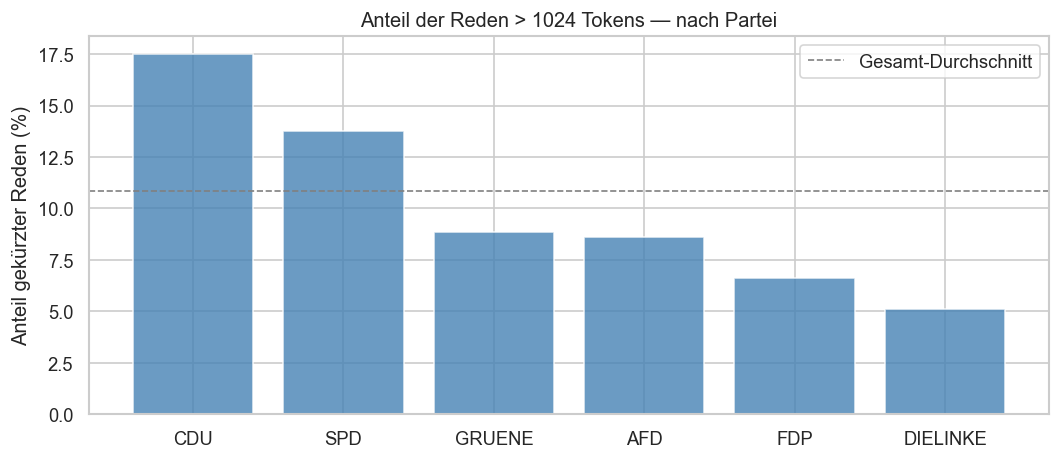

In [5]:
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("dbmdz/german-gpt2")
tokenizer.pad_token = tokenizer.eos_token

TOKEN_LIMIT = 1024

all_enriched["token_count"] = all_enriched["text"].apply(
    lambda t: len(tokenizer.encode(t, truncation=False)) if isinstance(t, str) else 0
)
all_enriched["truncated"] = all_enriched["token_count"] > TOKEN_LIMIT

total = len(all_enriched)
n_truncated = all_enriched["truncated"].sum()
print(f"Reden gesamt          : {total:,}")
print(f"Gekürzt (>{TOKEN_LIMIT} Tokens): {n_truncated:,}  ({n_truncated/total:.1%})")
print(f"Längste Rede          : {all_enriched['token_count'].max():,} Tokens")
print()

trunc_by_party = (
    all_enriched.groupby("party")["truncated"]
    .agg(n_speeches="count", n_truncated="sum")
    .assign(pct_truncated=lambda x: x["n_truncated"] / x["n_speeches"])
    .sort_values("pct_truncated", ascending=False)
)
display(trunc_by_party.style.format({"pct_truncated": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(trunc_by_party.index, trunc_by_party["pct_truncated"] * 100,
       color="steelblue", alpha=0.8)
ax.axhline(n_truncated / total * 100, color="gray", linestyle="--",
           linewidth=1, label="Gesamt-Durchschnitt")
ax.set_ylabel("Anteil gekürzter Reden (%)")
ax.set_title("Anteil der Reden > 1024 Tokens — nach Partei")
ax.legend()
plt.tight_layout()
plt.show()

## **Block C**: Explorative Datenanalyse

Deskriptiva je Partei, Verteilungs- und Zeitverlaufsplots, **Intraklassenkorrelation (ICC)** als empirische Begründung der Mehrebenenstruktur, sowie Konfundierungs-Checks (Partei × Regierungsstatus, Partei × Bildung, Surprisal ~ Länge), die die Kontrollvariablen in M2 motivieren.

In [6]:
# --- Deskriptive Tabelle je Partei ---
desc = (analysis.groupby("party", observed=True)
        .agg(n_reden=("surprisal", "size"),
             n_redner=("name", "nunique"),
             surprisal_M=("surprisal", "mean"),
             surprisal_SD=("surprisal", "std"),
             surprisal_Median=("surprisal", "median"),
             tokens_M=("n_tokens", "mean"),
             anteil_akademisch=("academic", "mean"),
             anteil_weiblich=("sex_cat", lambda s: (s == "weiblich").mean()),
             alter_M=("age_at_speech", "mean"))
        .reindex(PARTIES).round(3))
save_table(desc, "descriptives_by_party")
print("Deskriptiva je Partei (→ output/tables/descriptives_by_party.csv):")
display(desc)

# --- ICC aus Null-Modellen (Redner:in und Sitzungstag) ---
m_null_spk = fit_lmm("surprisal ~ 1", analysis, group="speaker_id")
m_null_day = fit_lmm("surprisal ~ 1", analysis, group="sitting_day")
icc_spk, g_spk, r_spk = icc(m_null_spk)
icc_day, g_day, r_day = icc(m_null_day)
RESULTS.update(icc_speaker=icc_spk, icc_sitting_day=icc_day)
print(f"\nICC Redner:in   = {icc_spk:.3f}  (Var_speaker={g_spk:.4f}, Var_resid={r_spk:.4f})")
print(f"ICC Sitzungstag = {icc_day:.3f}  (Var_day={g_day:.4f}, Var_resid={r_day:.4f})")
print(f"→ {icc_spk:.0%} der Surprisal-Varianz liegt zwischen Redner:innen ⇒ Random Intercept nötig.")

# --- Konfundierungs-Checks ---
ct_gov = pd.crosstab(analysis["party"], analysis["gov_status"], normalize="index").reindex(PARTIES).round(3)
acad_by_party = (analysis.groupby("party", observed=True)["academic"].mean()
                 .reindex(PARTIES).round(3).to_frame("anteil_akademisch"))
corr_len = analysis[["surprisal", "log_n_tokens"]].corr().iloc[0, 1]
RESULTS["corr_surprisal_logtokens"] = float(corr_len)
save_table(ct_gov, "confound_party_x_gov")
save_table(acad_by_party, "confound_party_x_academic")  
print("\nPartei × Regierungsstatus (Zeilenanteile):"); display(ct_gov)
print("Anteil akademisch je Partei:"); display(acad_by_party)
print(f"Korrelation surprisal ~ log_n_tokens: r = {corr_len:.3f}  "
      f"⇒ Länge ist ein Konfundierer und wird in M2 kontrolliert.")


Deskriptiva je Partei (→ output/tables/descriptives_by_party.csv):


,n_reden,n_redner,surprisal_M,surprisal_SD,surprisal_Median,tokens_M,anteil_akademisch,anteil_weiblich,alter_M
party,,,,,,,,,
CDU,10367,328,4.192,0.577,4.324,672.323,0.505,0.230,52.886
SPD,11770,355,4.134,0.567,4.220,664.916,0.447,0.439,51.383
GRUENE,8895,160,3.946,0.590,3.855,503.478,0.612,0.614,48.813
FDP,7731,121,3.940,0.567,3.876,493.953,0.521,0.184,51.834
DIELINKE,5840,102,3.881,0.568,3.766,453.337,0.429,0.559,53.291
AFD,7079,112,4.118,0.601,4.069,462.682,0.427,0.096,54.230



ICC Redner:in   = 0.195  (Var_speaker=0.0672, Var_resid=0.2771)
ICC Sitzungstag = 0.084  (Var_day=0.0297, Var_resid=0.3240)
→ 20% der Surprisal-Varianz liegt zwischen Redner:innen ⇒ Random Intercept nötig.

Partei × Regierungsstatus (Zeilenanteile):


gov_status,Opposition,Regierung
party,,
CDU,0.441,0.559
SPD,0.000,1.000
GRUENE,0.528,0.472
FDP,0.548,0.452
DIELINKE,1.000,0.000
AFD,1.000,0.000


Anteil akademisch je Partei:


,anteil_akademisch
party,
CDU,0.505
SPD,0.447
GRUENE,0.612
FDP,0.521
DIELINKE,0.429
AFD,0.427


Korrelation surprisal ~ log_n_tokens: r = 0.666  ⇒ Länge ist ein Konfundierer und wird in M2 kontrolliert.


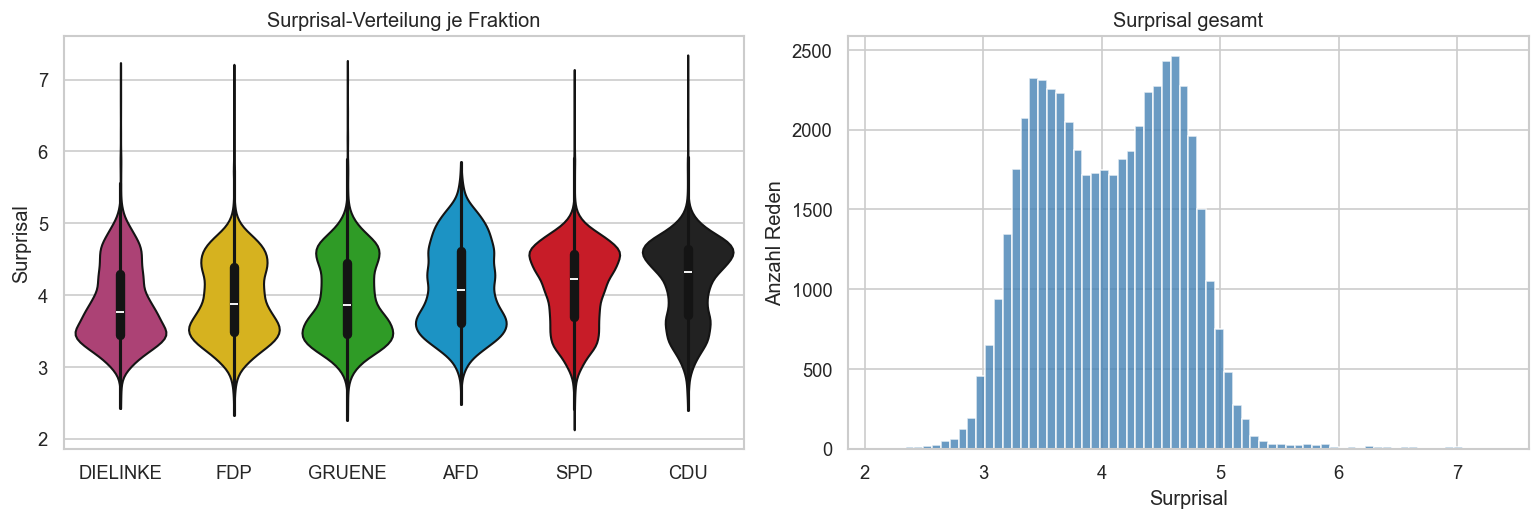

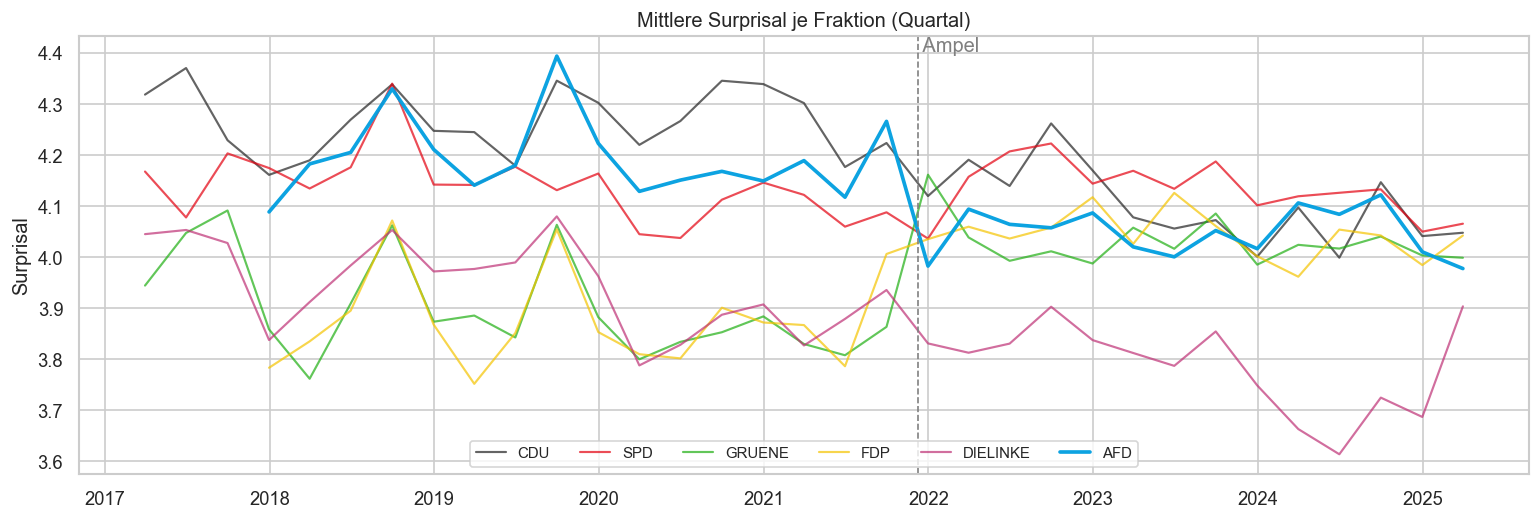

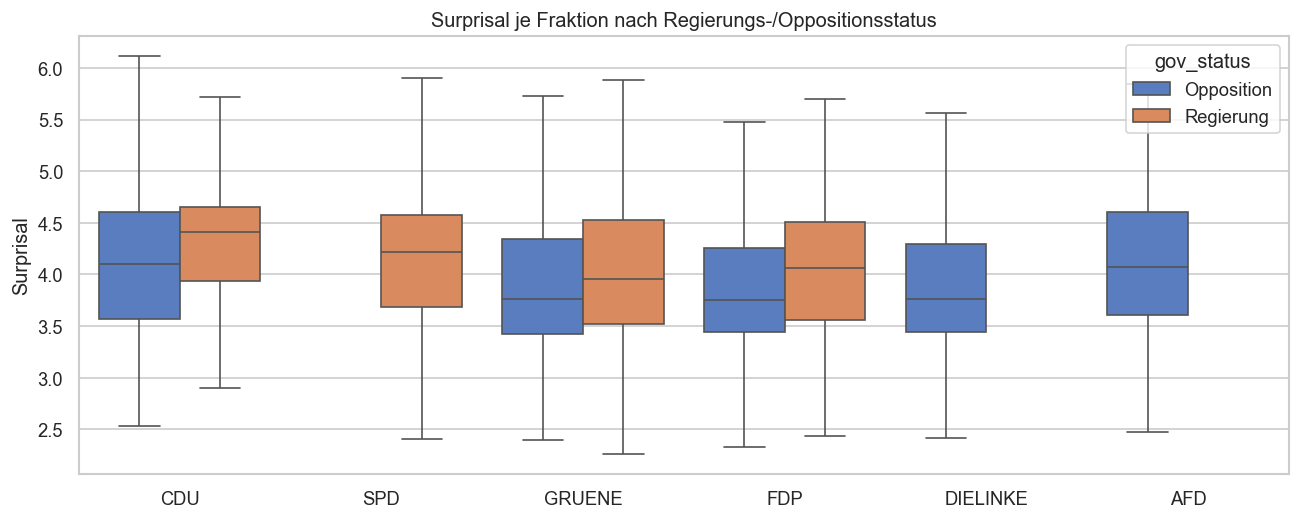

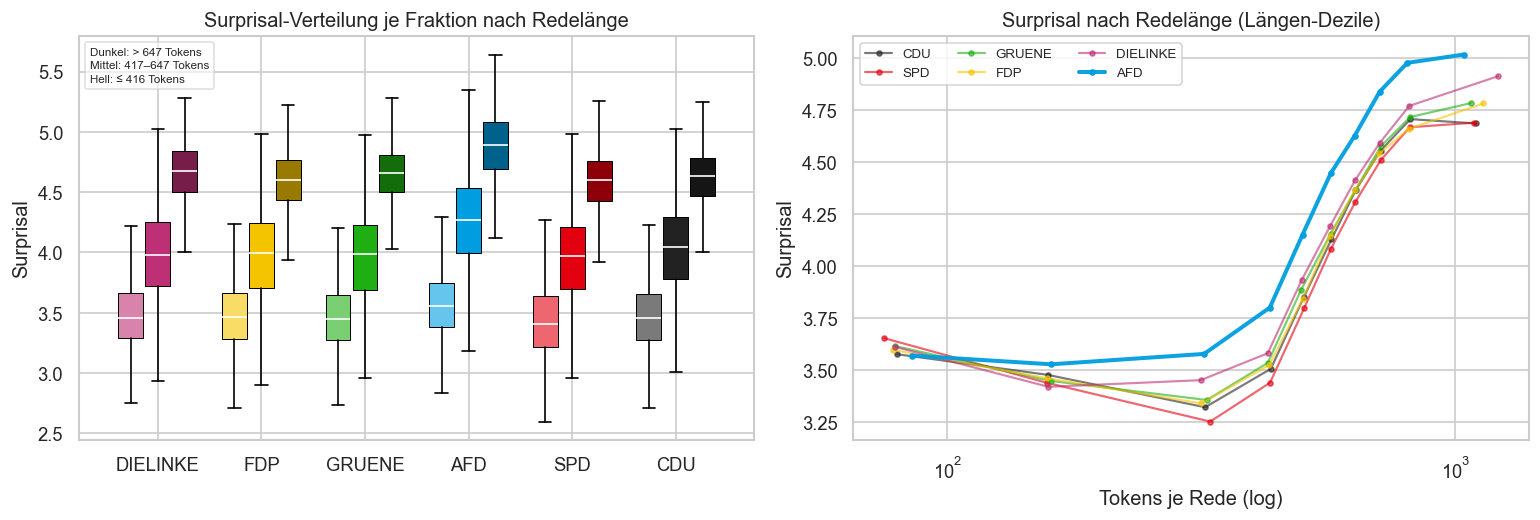

Abbildungen gespeichert → output/figures/{dist_by_party,timeseries_by_party,surprisal_by_gov,surprisal_by_length}.png


In [7]:
# --- Verteilungs- & Zeitverlaufsplots ---
PARTY_COLORS = {"AFD": "#009EE0", "CDU": "#222222", "SPD": "#E3000F",
                "GRUENE": "#1FAF12", "FDP": "#F5C400", "DIELINKE": "#BE3075"}
order_by_mean = analysis.groupby("party", observed=True)["surprisal"].mean().sort_values().index.tolist()

# --- Verteilung Surprisal je Partei (Violin) + Histogramm gesamt ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.violinplot(data=analysis, x="party", y="surprisal", order=order_by_mean,
               hue="party", palette=PARTY_COLORS, legend=False, cut=0, ax=axes[0])
axes[0].set(title="Surprisal-Verteilung je Fraktion", xlabel="", ylabel="Surprisal")
axes[1].hist(analysis["surprisal"], bins=70, color="steelblue", alpha=0.8)
axes[1].set(title="Surprisal gesamt", xlabel="Surprisal", ylabel="Anzahl Reden")
plt.tight_layout(); plt.savefig(FIG/"dist_by_party.png"); plt.show()

# --- Zeitverlauf: mittlere Surprisal je Partei je Quartal ---
ts = (analysis.set_index("date").groupby("party", observed=True)["surprisal"]
      .resample("QE").mean().reset_index())
fig, ax = plt.subplots(figsize=(13, 4.5))
for p in PARTIES:
    sub = ts[ts["party"] == p]
    ax.plot(sub["date"], sub["surprisal"], color=PARTY_COLORS[p], label=p,
            linewidth=2.2 if p == "AFD" else 1.3, alpha=0.95 if p == "AFD" else 0.7)
ax.axvline(GROKO_END, color="gray", ls="--", lw=1); ax.text(GROKO_END, ax.get_ylim()[1], " Ampel", va="top", color="gray")
ax.set(title="Mittlere Surprisal je Fraktion (Quartal)", xlabel="", ylabel="Surprisal")
ax.legend(ncol=6, fontsize=9, loc="lower center")
plt.tight_layout(); plt.savefig(FIG/"timeseries_by_party.png"); plt.show()

# --- Roh-Vorschau: Surprisal × Partei, getrennt nach Regierungsstatus ---
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.boxplot(data=analysis, x="party", y="surprisal", hue="gov_status", order=PARTIES,
            showfliers=False, ax=ax)
ax.set(title="Surprisal je Fraktion nach Regierungs-/Oppositionsstatus", xlabel="", ylabel="Surprisal")
plt.tight_layout(); plt.savefig(FIG/"surprisal_by_gov.png"); plt.show()
# --- Suppressionseffekt sichtbar machen: Surprisal je Fraktion nach Redelänge ---
# Redelänge ist der stärkste Confounder (kürzere Reden -> niedrigere Surprisal).
# Stratifiziert man danach, tritt der bei gleicher Länge erhöhte AfD-Wert hervor.
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

def _shade(color, amt):
    """amt>0 -> dunkler (Richtung Schwarz), amt<0 -> heller (Richtung Weiß)."""
    c = np.array(mcolors.to_rgb(color))
    return tuple(c * (1 - amt)) if amt >= 0 else tuple(c + (1 - c) * (-amt))

edges = analysis["n_tokens"].quantile([0, 1/3, 2/3, 1]).round().astype(int).tolist()
band_code = pd.qcut(analysis["n_tokens"], 3, labels=[0, 1, 2]).astype(int)
SHADES, OFFS = [-0.40, 0.0, 0.38], [-0.26, 0.0, 0.26]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
# (a) Verteilung je Fraktion in Fraktionsfarbe; Helligkeit = Redelänge (light->dark = kurz->lang)
for i, p in enumerate(order_by_mean):
    for code, off, amt in zip([0, 1, 2], OFFS, SHADES):
        vals = analysis.loc[(analysis["party"] == p) & (band_code == code), "surprisal"].dropna().values
        fc = _shade(PARTY_COLORS[p], amt)
        bp = axes[0].boxplot(vals, positions=[i + off], widths=0.24, patch_artist=True, showfliers=False)
        bp["boxes"][0].set(facecolor=fc, edgecolor="black", linewidth=0.6)
        lum = 0.2126 * fc[0] + 0.7152 * fc[1] + 0.0722 * fc[2]
        bp["medians"][0].set(color="white", linewidth=1.0)
axes[0].set_xticks(range(len(order_by_mean))); axes[0].set_xticklabels(order_by_mean)
axes[0].set(title="Surprisal-Verteilung je Fraktion nach Redelänge", xlabel="", ylabel="Surprisal")
band_labels = [f"Dunkel: > {edges[2]} Tokens", f"Mittel: {edges[1]+1}–{edges[2]} Tokens", f"Hell: ≤ {edges[1]} Tokens"]
axes[0].legend([Line2D([], [], linestyle="none")] * 3, band_labels, loc="upper left",
               fontsize=7, handlelength=0, handletextpad=0, labelspacing=0.3,
               borderpad=0.4, framealpha=0.6)
# (b) Mittlere Surprisal über die Längenverteilung, je Fraktion (Längen-Dezile)
binned = analysis.assign(_len_bin=pd.qcut(analysis["n_tokens"], 10, duplicates="drop"))
prof = (binned.groupby(["_len_bin", "party"], observed=True)
        .agg(surprisal=("surprisal", "mean"), x=("n_tokens", "median")).reset_index())
for p in PARTIES:
    sub = prof[prof["party"] == p]
    axes[1].plot(sub["x"], sub["surprisal"], color=PARTY_COLORS[p], label=p, marker="o", ms=3,
                 linewidth=2.4 if p == "AFD" else 1.3, alpha=0.95 if p == "AFD" else 0.6)
axes[1].set_xscale("log")
axes[1].set(title="Surprisal nach Redelänge (Längen-Dezile)", xlabel="Tokens je Rede (log)", ylabel="Surprisal")
axes[1].legend(ncol=3, fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"surprisal_by_length.png"); plt.show()

print("Abbildungen gespeichert → output/figures/{dist_by_party,timeseries_by_party,surprisal_by_gov,surprisal_by_length}.png")

## **Block D:** Hauptmodell H1

**H1:** Die mittlere Sprachkomplexität (Surprisal) von AfD-Reden im Bundestag
ist höher als die der übrigen Fraktionen, auch unter Kontrolle von Redelänge,
Regierungsstatus, Zeit und personenbezogenen Merkmalen.

Geschachtelte LMM mit Random Intercept für Redner:in; der Partei-Effekt wird *zwischen* Personen geschätzt:
 
>Die statistische Power liegt auf **Redner:innen-Ebene** (112 AfD- vs. ~1.068 andere), nicht bei 83k Reden.

- **M0:** `surprisal ~ 1 + (1|speaker)` → ICC
- **M1:** `surprisal ~ is_afd + (1|speaker)`
- **M2 (Hauptspezifikation):** `+ log_n_tokens + gov_status + date_num + sex_cat + age + academic (+ NA-Indikatoren)`
- **M2b:** wie M2, aber `party` (6 Stufen) + alle paarweisen Kontraste (Holm-korrigiert)

Berichtet werden roher β **und** standardisiertes d (z-DV), 95%-CI, AIC/BIC/LRT, ICC und Pseudo-R².

In [8]:
# --- Block D1 — M2 Hauptmodell + Modellvergleich M0/M1/M2 ---
COVARS = "log_n_tokens + C(gov_status) + date_num + C(sex_cat) + age_imp + age_na + academic + edu_missing"
f_m2 = f"surprisal ~ is_afd + {COVARS}"

# REML-Fits für Effektschätzung/CI. Separate REML-Fits von M0/M1 entfallen:
# M0 ist identisch mit m_null_spk aus Block C1, und für den LRT-Modellvergleich
# werden M0–M2 unten ohnehin mit ML neu geschätzt — die alten Fits waren ungenutzt.
m2   = fit_lmm(f_m2, analysis)
m2_z = fit_lmm(f"surprisal_z ~ is_afd + {COVARS}", analysis)   # z-DV → β direkt als Cohen's d lesbar

# Koeffiziententabelle M2 (roh) + standardisierter Effekt
coef_m2 = lmm_coefs(m2)
coef_m2["beta_std(z-DV)"] = lmm_coefs(m2_z)["beta"]
save_table(coef_m2.round(4), "main_models_M2_coefs")

d_afd = float(m2_z.fe_params["is_afd"]); ci_z = m2_z.conf_int().loc["is_afd"]
RESULTS.update(afd_beta_raw=float(m2.fe_params["is_afd"]),
               afd_d=d_afd, afd_d_lo=float(ci_z[0]), afd_d_hi=float(ci_z[1]))

# Modellvergleich (ML-Fits für LRT)
comp = model_comparison(
    [fit_lmm("surprisal ~ 1", analysis, reml=False),
     fit_lmm("surprisal ~ is_afd", analysis, reml=False),
     fit_lmm(f_m2, analysis, reml=False)],
    ["M0 (Null)", "M1 (is_afd)", "M2 (adjustiert)"])
save_table(comp.round(2), "main_models_comparison")

r2m, r2c = pseudo_r2(m2, analysis); icc_m2, _, _ = icc(m2)
RESULTS.update(pseudo_r2_marginal=float(r2m), pseudo_r2_conditional=float(r2c))

# Interpretation aus den Schätzwerten
richtung = ("KOMPLEXER (höhere Surprisal) — konsistent mit H1" if d_afd > 0
            else "EINFACHER (niedrigere Surprisal) — entgegen H1")
ci_excl0 = (ci_z[0] > 0) or (ci_z[1] < 0)
print("H1-Test — adjustierter AfD-Effekt (M2):")
print(f"  roh:            β = {m2.fe_params['is_afd']:+.4f} Surprisal-Einheiten")
print(f"  standardisiert: d = {d_afd:+.3f}   95%-CI [{ci_z[0]:+.3f}, {ci_z[1]:+.3f}]"
      f"   (CI {'schließt 0 aus' if ci_excl0 else 'schließt 0 EIN'})")
print(f"  Pseudo-R²: marginal {r2m:.3f} / conditional {r2c:.3f}  ·  ICC(M2) {icc_m2:.3f}")
print(f"\n→ AfD spricht im Mittel {richtung}.")
print(f"  Effektstärke nach Cohen: {cohen_label(d_afd)} (|d|={abs(d_afd):.2f}); "
      f"p-Werte bei N={len(analysis):,} nicht aussagekräftig.")
display(coef_m2.round(4)); display(comp.round(2))


H1-Test — adjustierter AfD-Effekt (M2):
  roh:            β = +0.1293 Surprisal-Einheiten
  standardisiert: d = +0.219   95%-CI [+0.154, +0.284]   (CI schließt 0 aus)
  Pseudo-R²: marginal 0.462 / conditional 0.546  ·  ICC(M2) 0.157

→ AfD spricht im Mittel KOMPLEXER (höhere Surprisal) — konsistent mit H1.
  Effektstärke nach Cohen: klein (|d|=0.22); p-Werte bei N=51,682 nicht aussagekräftig.


,beta,se,ci_low,ci_high,p,beta_std(z-DV)
Intercept,0.7188,0.1417,0.4411,0.9965,0.0000,-5.6597
C(gov_status)[T.Regierung],0.0367,0.0061,0.0247,0.0486,0.0000,0.0622
C(sex_cat)[T.männlich],0.3351,0.1366,0.0674,0.6028,0.0141,0.5688
C(sex_cat)[T.unbekannt],0.2351,0.1499,-0.0587,0.5290,0.1168,0.3991
C(sex_cat)[T.weiblich],0.2846,0.1367,0.0168,0.5525,0.0373,0.4831
is_afd,0.1293,0.0195,0.0910,0.1675,0.0000,0.2194
log_n_tokens,0.4974,0.0026,0.4923,0.5025,0.0000,0.8442
date_num,-0.0063,0.0010,-0.0083,-0.0043,0.0000,-0.0107
age_imp,0.0005,0.0005,-0.0004,0.0014,0.2938,0.0009
age_na,0.0258,0.0376,-0.0479,0.0996,0.4922,0.0439


,k_fixed,logLik,AIC,BIC,LRT_chi2,LRT_df,LRT_p
model,,,,,,,
M0 (Null),1,-41352.53,82711.06,82737.62,NaN,NaN,NaN
M1 (is_afd),2,-41352.53,82713.05,82748.46,0.01,1.0,0.92
M2 (adjustiert),12,-27107.87,54243.74,54367.68,28489.31,10.0,0.00


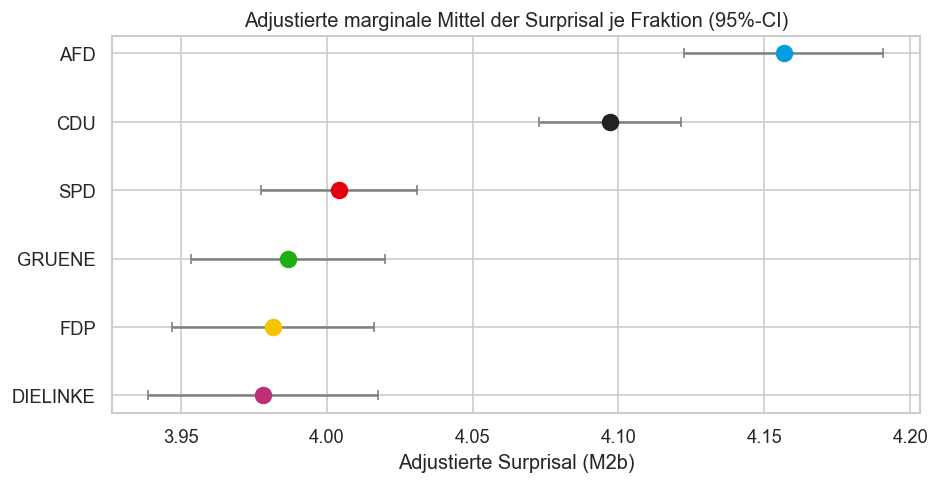

Adjustierte marginale Mittel je Fraktion:


,adj_mean,se,ci_low,ci_high
CDU,4.097,0.012,4.073,4.121
SPD,4.004,0.014,3.978,4.031
GRUENE,3.987,0.017,3.953,4.020
FDP,3.982,0.018,3.947,4.016
DIELINKE,3.978,0.020,3.939,4.018
AFD,4.157,0.017,4.123,4.191


Paarweise AfD-Kontraste (Holm-korrigiert) — positiv ⇒ AfD komplexer:


,Kontrast,diff,se,p_raw,p_holm
4,CDU−AFD,-0.0596,0.0210,0.0046,0.0325
8,SPD−AFD,-0.1524,0.0216,0.0000,0.0000
11,GRUENE−AFD,-0.1700,0.0240,0.0000,0.0000
13,FDP−AFD,-0.1750,0.0246,0.0000,0.0000
14,DIELINKE−AFD,-0.1785,0.0260,0.0000,0.0000


In [9]:
# --- Parteienvergleich, adjustierte marginale Mittel ---
from itertools import combinations
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

f_m2b = f"surprisal ~ C(party) + {COVARS}"
m2b = fit_lmm(f_m2b, analysis)

# --- Referenzraster: Kovariaten auf Mittel (kontinuierlich) bzw. Referenz (kategorial) ---
hold = {c: analysis[c].mean() for c in ["log_n_tokens", "date_num", "age_imp", "age_na", "academic", "edu_missing"]}
grid = pd.DataFrame({"party": pd.Categorical(PARTIES, categories=PARTIES),
                     "gov_status": "Opposition", "sex_cat": "männlich",
                     **{k: v for k, v in hold.items()}})

mean, se = adjusted_means(m2b, grid)
emm = pd.DataFrame({"adj_mean": mean, "se": se, "ci_low": mean-1.96*se, "ci_high": mean+1.96*se},
                   index=PARTIES)
save_table(emm.round(4), "emmeans_party")
RESULTS["emmeans"] = {k: round(v, 3) for k, v in emm["adj_mean"].items()}

# --- Forest-Plot der adjustierten Mittel ---
emm_s = emm.sort_values("adj_mean")
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.errorbar(emm_s["adj_mean"], range(len(emm_s)), xerr=1.96*emm_s["se"],
            fmt="none", ecolor="gray", capsize=3, zorder=1)
for i, (p, row) in enumerate(emm_s.iterrows()):
    ax.scatter(row["adj_mean"], i, color=PARTY_COLORS[p], s=90, zorder=2)
ax.set_yticks(range(len(emm_s))); ax.set_yticklabels(emm_s.index)
ax.set(title="Adjustierte marginale Mittel der Surprisal je Fraktion (95%-CI)",
       xlabel="Adjustierte Surprisal (M2b)")
plt.tight_layout(); plt.savefig(FIG/"emmeans_party.png"); plt.show()

# --- Alle paarweisen Kontraste, Holm-korrigiert ---
fe = m2b.fe_params; cov = m2b.cov_params().loc[fe.index, fe.index].values
Xg = np.asarray(patsy.build_design_matrices([m2b.model.data.design_info], grid)[0])
rows = []
for i, j in combinations(range(len(PARTIES)), 2):
    c = Xg[i] - Xg[j]
    est = float(c @ fe.values); se_c = float(np.sqrt(c @ cov @ c))
    rows.append({"Kontrast": f"{PARTIES[i]}−{PARTIES[j]}", "diff": est, "se": se_c,
                 "p_raw": 2*norm.sf(abs(est/se_c))})
contr = pd.DataFrame(rows)
contr["p_holm"] = multipletests(contr["p_raw"], method="holm")[1]
save_table(contr.round(4), "pairwise_contrasts_party", index=False)

print("Adjustierte marginale Mittel je Fraktion:"); display(emm.round(3))
print("Paarweise AfD-Kontraste (Holm-korrigiert) — positiv ⇒ AfD komplexer:")
display(contr[contr["Kontrast"].str.contains("AFD")].round(4))

## **Block E:** Explorative Erweiterungen


- **Partei × Zeit:** Verändert sich die relative Komplexität der AfD über 2017–2025?
- **Opposition vs. Populismus:** Ist der Effekt AfD-spezifisch oder ein allgemeiner Oppositionseffekt? (AfD & DIELINKE durchgehend Opposition ⇒ trennbar.)
- **Bildungsparadox:** Treiben die *akademischen* AfD-Redner:innen die höhere Komplexität? (`is_afd × academic`)
- **Populismus:** Gilt ein Effekt für „Populismus" allgemein (AfD rechts, DIELINKE links) oder spezifisch für die AfD?

is_afd × date_num: β = -0.0088 Surprisal/Jahr  95%-CI [-0.0143, -0.0032]
  >0 ⇒ AfD-Vorsprung wächst über Zeit · <0 ⇒ er schrumpft.


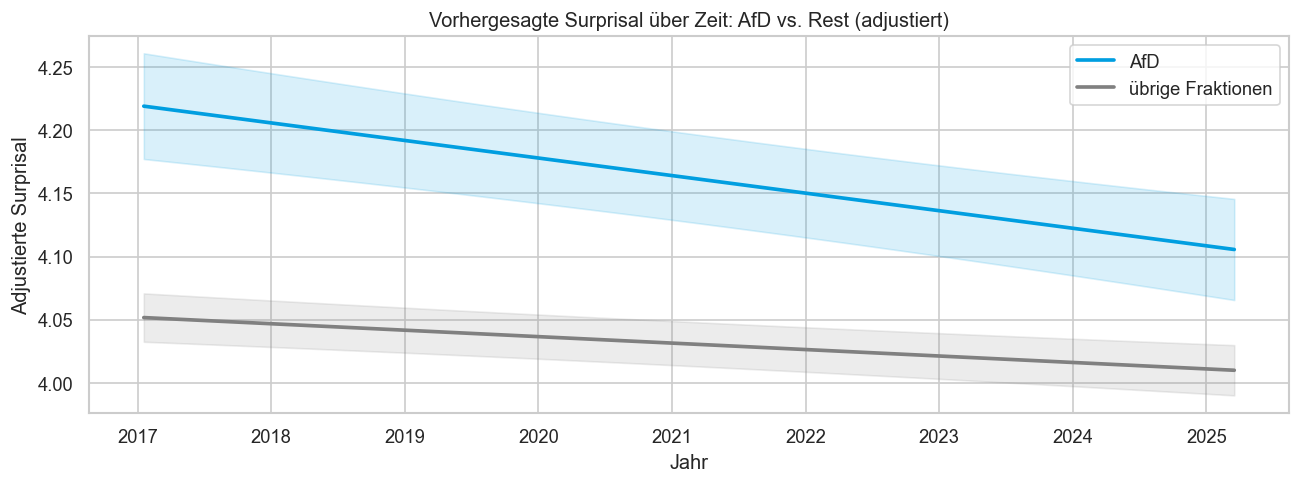

In [10]:
# --- Partei × Zeit-Interaktion (explorativ) ---
m_time = fit_lmm(f"surprisal ~ is_afd * date_num + {COVARS}", analysis)
b_int = float(m_time.fe_params["is_afd:date_num"]); ci_int = m_time.conf_int().loc["is_afd:date_num"]
RESULTS["afd_x_time_beta"] = b_int
print(f"is_afd × date_num: β = {b_int:+.4f} Surprisal/Jahr  95%-CI [{ci_int[0]:+.4f}, {ci_int[1]:+.4f}]")
print("  >0 ⇒ AfD-Vorsprung wächst über Zeit · <0 ⇒ er schrumpft.")

# --- Vorhergesagte Verläufe AfD vs. Rest ---
drange = np.linspace(analysis["date_num"].min(), analysis["date_num"].max(), 40)
base = {c: analysis[c].mean() for c in ["log_n_tokens", "age_imp", "age_na", "academic", "edu_missing"]}
gridt = pd.DataFrame([{"is_afd": a, "date_num": d, "gov_status": "Opposition", "sex_cat": "männlich", **base}
                      for a in (0, 1) for d in drange])
pt, st = adjusted_means(m_time, gridt)
gridt["pred"], gridt["lo"], gridt["hi"] = pt, pt-1.96*st, pt+1.96*st
gridt["jahr"] = 2017 + gridt["date_num"]

fig, ax = plt.subplots(figsize=(11, 4.2))
for a, lab, col in [(1, "AfD", PARTY_COLORS["AFD"]), (0, "übrige Fraktionen", "gray")]:
    g = gridt[gridt["is_afd"] == a]
    ax.plot(g["jahr"], g["pred"], color=col, lw=2.2, label=lab)
    ax.fill_between(g["jahr"], g["lo"], g["hi"], color=col, alpha=0.15)
ax.set(title="Vorhergesagte Surprisal über Zeit: AfD vs. Rest (adjustiert)",
       xlabel="Jahr", ylabel="Adjustierte Surprisal"); ax.legend()
plt.tight_layout(); plt.savefig(FIG/"interaction_afd_time.png"); plt.show()

In [11]:
# --- Opposition vs. Populismus (explorativ) ---
COVARS_NOGOV = "log_n_tokens + date_num + C(sex_cat) + age_imp + age_na + academic + edu_missing"

# Allgemeiner Regierungs-/Oppositionseffekt (aus M2)
b_gov = m2.fe_params["C(gov_status)[T.Regierung]"]; ci_gov = m2.conf_int().loc["C(gov_status)[T.Regierung]"]
RESULTS["gov_effect_beta"] = float(b_gov)
print(f"Regierung vs. Opposition (Haupteffekt, roh): β = {b_gov:+.4f}  "
      f"CI[{ci_gov[0]:+.4f}, {ci_gov[1]:+.4f}]  (>0 ⇒ Regierungsreden komplexer)")
print("    (is_afd × gov_status nicht schätzbar — AfD regiert nie)")

# Nur innerhalb der Oppositionsreden: AfD vs. übrige Opposition
opp = analysis[analysis["gov_status"] == "Opposition"].copy()
opp["surprisal_z"] = (opp["surprisal"] - opp["surprisal"].mean()) / opp["surprisal"].std()
m_opp_z = fit_lmm(f"surprisal_z ~ is_afd + {COVARS_NOGOV}", opp)
d_opp = float(m_opp_z.fe_params["is_afd"]); ci_opp = m_opp_z.conf_int().loc["is_afd"]
RESULTS["afd_d_within_opposition"] = d_opp
print(f"AfD vs. übrige Opposition (nur Oppositionsreden, N={len(opp):,}):")
print(f"    d = {d_opp:+.3f}  95%-CI [{ci_opp[0]:+.3f}, {ci_opp[1]:+.3f}]")
print(f"    → bleibt der Effekt bestehen, ist er AfD-spezifisch und KEIN reiner Oppositionseffekt.")

Regierung vs. Opposition (Haupteffekt, roh): β = +0.0367  CI[+0.0247, +0.0486]  (>0 ⇒ Regierungsreden komplexer)
    (is_afd × gov_status nicht schätzbar — AfD regiert nie)
AfD vs. übrige Opposition (nur Oppositionsreden, N=26,427):
    d = +0.204  95%-CI [+0.130, +0.278]
    → bleibt der Effekt bestehen, ist er AfD-spezifisch und KEIN reiner Oppositionseffekt.


In [12]:
# --- is_afd × academic ---
COVARS_NOACAD = "log_n_tokens + C(gov_status) + date_num + C(sex_cat) + age_imp + age_na + edu_missing"
m_edu = fit_lmm(f"surprisal ~ is_afd * academic + {COVARS_NOACAD}", analysis)
b_edu = float(m_edu.fe_params["is_afd:academic"]); ci_edu = m_edu.conf_int().loc["is_afd:academic"]
RESULTS["afd_x_academic_beta"] = b_edu
base_e = {c: analysis[c].mean() for c in ["log_n_tokens", "date_num", "age_imp", "age_na", "edu_missing"]}
grid_e = pd.DataFrame([{"is_afd": a, "academic": ac, "gov_status": "Opposition", "sex_cat": "männlich", **base_e}
                       for a in (0, 1) for ac in (0, 1)])
me, _ = adjusted_means(m_edu, grid_e)
grid_e["adj_mean"] = me
tab_edu = grid_e.pivot_table(index="is_afd", columns="academic", values="adj_mean")
tab_edu.index = ["übrige", "AfD"]; tab_edu.columns = ["nicht-akad.", "akademisch"]
save_table(tab_edu.round(3), "education_paradox_2x2")
print(f"is_afd × academic: β = {b_edu:+.4f}  CI[{ci_edu[0]:+.4f}, {ci_edu[1]:+.4f}]")
print("Adjustierte Surprisal (2×2):"); display(tab_edu.round(3))

# --- Populismus-Varianten (AfD rechts, DIELINKE links, Rest mainstream) ---
# Hinweis: BSW ist im Datensatz nicht separat enthalten (nur 6 Fraktionen); DIELINKE = linkspopuläre Vergleichsgruppe.
analysis["pop_group"] = pd.Categorical(
    np.select([analysis["party"] == "AFD", analysis["party"] == "DIELINKE"],
              ["rechts_pop", "links_pop"], default="mainstream"),
    categories=["mainstream", "links_pop", "rechts_pop"])
m_pop = fit_lmm(f"surprisal ~ C(pop_group) + {COVARS}", analysis)
base_p = {c: analysis[c].mean() for c in ["log_n_tokens", "date_num", "age_imp", "age_na", "academic", "edu_missing"]}
grid_p = pd.DataFrame({"pop_group": pd.Categorical(["mainstream", "links_pop", "rechts_pop"],
                                                   categories=["mainstream", "links_pop", "rechts_pop"]),
                       "gov_status": "Opposition", "sex_cat": "männlich", **base_p})
mp, sp = adjusted_means(m_pop, grid_p)
emm_pop = pd.DataFrame({"adj_mean": mp, "ci_low": mp-1.96*sp, "ci_high": mp+1.96*sp},
                       index=["mainstream", "links_pop (DIELINKE)", "rechts_pop (AfD)"])
save_table(emm_pop.round(4), "populism_gradient")
RESULTS["pop_gradient"] = {k: round(v, 3) for k, v in emm_pop["adj_mean"].items()}
print("Adjustierte Surprisal nach Populismus-Gruppe:"); display(emm_pop.round(3))
print("→ Ist nur 'rechts_pop' erhöht, ist der Effekt AfD-spezifisch und kein allgemeiner Populismus-Effekt.")

is_afd × academic: β = +0.0384  CI[-0.0380, +0.1147]
Adjustierte Surprisal (2×2):


,nicht-akad.,akademisch
übrige,4.051,4.004
AfD,4.167,4.157


Adjustierte Surprisal nach Populismus-Gruppe:


,adj_mean,ci_low,ci_high
mainstream,4.034,4.016,4.052
links_pop (DIELINKE),3.984,3.944,4.024
rechts_pop (AfD),4.157,4.122,4.192


→ Ist nur 'rechts_pop' erhöht, ist der Effekt AfD-spezifisch und kein allgemeiner Populismus-Effekt.


## **Block F:** Robustheit & Validität

- **Triangulation:** Surprisal ist nur *ein* Maß. Vergleich mit klassischen Lesbarkeitsindizes (LIX, deutsche Flesch-/Amstad-Formel, Wiener Sachtextformel); M2 mit jedem Maß als DV.
- **Längen-Sensitivität:** Hauptmodell für Mindestlängen 30/50/100 Tokens.
- **Gekreuzte Ebene:** Cluster-robuste SE (Redner:in & Sitzungstag).
- **Sensitivität:** FDP ab dem Koalitionsbruch (2024-11-06) als Opposition kodiert.
- **Diagnostik:** Residuen, QQ-Plot, Verteilung der Random Intercepts.
- LLM-Validitätslimitation + multiples Testen (Textnotiz).

Lesbarkeitsindizes berechnet (51,682 Reden, 15s)


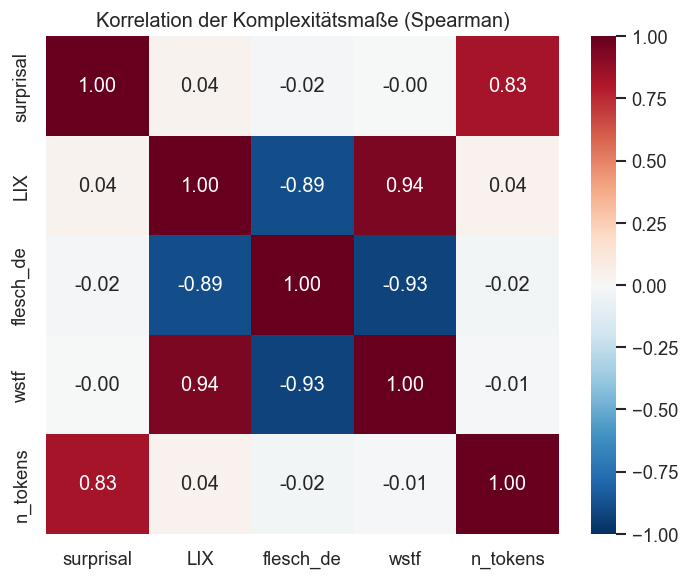

AfD-Effekt (d) je Komplexitätsmaß — konsistent, wenn LIX/WSTF>0 und Flesch<0:


,Maß,Richtung,is_afd_d,ci_low,ci_high
0,surprisal,↑schwerer,0.219,0.154,0.284
1,LIX,↑schwerer,0.098,-0.003,0.199
2,flesch_de,↑leichter,-0.119,-0.226,-0.011
3,wstf,↑schwerer,0.190,0.080,0.300


In [13]:
# -- Lesbarkeitsindizes pro Rede (Silben via pyphen) --
dic = pyphen.Pyphen(lang="de_DE"); _syl = {}
def syl(w):
    w = w.lower()
    if w not in _syl:
        _syl[w] = dic.inserted(w).count("-") + 1
    return _syl[w]
def readability(text, n_sent):
    words = WORD.findall(str(text)); n = len(words)
    if n == 0:
        return (np.nan, np.nan, np.nan)
    s = [syl(w) for w in words]
    long6 = sum(1 for w in words if len(w) > 6)
    asl, asw = n/n_sent, sum(s)/n
    lix = asl + 100*long6/n                       # LIX (höher = schwerer)
    flesch = 180 - asl - 58.5*asw                 # Flesch/Amstad (höher = LEICHTER)
    ms = 100*sum(1 for x in s if x >= 3)/n; 
    es = 100*sum(1 for x in s if x == 1)/n; 
    iw = 100*long6/n
    wstf = 0.1935*ms + 0.1672*asl + 0.1297*iw - 0.0327*es - 0.875   # Wiener Sachtextformel (höher = schwerer)
    return (lix, flesch, wstf)

t0 = time.time()
rb = analysis.apply(lambda r: readability(r["text"], r["n_sentences"]), axis=1, result_type="expand")
analysis[["LIX", "flesch_de", "wstf"]] = rb.values
print(f"Lesbarkeitsindizes berechnet ({len(analysis):,} Reden, {time.time()-t0:.0f}s)")

# -- Korrelationsmatrix (Spearman) --
measures = ["surprisal", "LIX", "flesch_de", "wstf", "n_tokens"]
corr = analysis[measures].corr(method="spearman")
save_table(corr.round(3), "triangulation_corr")
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Korrelation der Komplexitätsmaße (Spearman)")
plt.tight_layout(); plt.savefig(FIG/"triangulation_corr.png"); plt.show()

# -- M2 mit jedem Maß als (z-)DV: bleibt der AfD-Effekt richtungskonsistent? --
res_tri = []
for dv, direction in [("surprisal", "↑schwerer"), ("LIX", "↑schwerer"),
                      ("flesch_de", "↑leichter"), ("wstf", "↑schwerer")]:
    analysis["_dvz"] = (analysis[dv] - analysis[dv].mean()) / analysis[dv].std()
    mm = fit_lmm(f"_dvz ~ is_afd + {COVARS}", analysis)
    ci = mm.conf_int().loc["is_afd"]
    res_tri.append({"Maß": dv, "Richtung": direction, "is_afd_d": mm.fe_params["is_afd"],
                    "ci_low": ci[0], "ci_high": ci[1]})
tri = pd.DataFrame(res_tri)
save_table(tri.round(3), "triangulation_afd_effect", index=False)
RESULTS["triangulation"] = {r["Maß"]: round(r["is_afd_d"], 3) for _, r in tri.iterrows()}
print("AfD-Effekt (d) je Komplexitätsmaß — konsistent, wenn LIX/WSTF>0 und Flesch<0:")
display(tri.round(3))

In [14]:
# --- Hauptmodell für Mindestlängen 30 / 50 / 100 Tokens ---
rows = []
for thr in [30, 50, 100]:
    sub = speeches_all[~speeches_all["is_procedural"] & (speeches_all["n_tokens"] >= thr)].copy()
    sub["_z"] = (sub["surprisal"] - sub["surprisal"].mean()) / sub["surprisal"].std()
    mm = fit_lmm(f"_z ~ is_afd + {COVARS}", sub)
    ci = mm.conf_int().loc["is_afd"]
    rows.append({"min_tokens": thr, "N": len(sub), "is_afd_d": mm.fe_params["is_afd"],
                 "ci_low": ci[0], "ci_high": ci[1]})
sens = pd.DataFrame(rows)
save_table(sens.round(3), "length_sensitivity", index=False)
print("AfD-Effekt (d) je Mindestlänge — stabil ⇒ robust:")
display(sens.round(3))

# --- OLS mit cluster-robusten SE (Redner:in / Sitzungstag) ---
ols = smf.ols(f"surprisal ~ is_afd + {COVARS}", analysis)
fit_spk = ols.fit(cov_type="cluster", cov_kwds={"groups": analysis["speaker_id"]})
fit_day = ols.fit(cov_type="cluster", cov_kwds={"groups": analysis["sitting_day"]})
clu = pd.DataFrame({
    "Spezifikation": ["MixedLM (1|speaker)", "OLS cluster=speaker", "OLS cluster=sitting_day"],
    "is_afd_beta": [m2.fe_params["is_afd"], fit_spk.params["is_afd"], fit_day.params["is_afd"]],
    "se":          [m2.bse_fe["is_afd"], fit_spk.bse["is_afd"], fit_day.bse["is_afd"]],
})
clu["ci_low"], clu["ci_high"] = clu["is_afd_beta"]-1.96*clu["se"], clu["is_afd_beta"]+1.96*clu["se"]
save_table(clu.round(4), "cluster_robust_afd", index=False)
RESULTS["afd_beta_ols_speakercluster"] = float(fit_spk.params["is_afd"])
print(" AfD-Koeffizient (roh) unter verschiedenen Fehler-Spezifikationen — Richtung konsistent:")
display(clu.round(4))

# --- Sensitivität: FDP ab 2024-11-06 (Koalitionsbruch) als Opposition kodiert ---
m2_fdp = fit_lmm(f_m2.replace("gov_status", "gov_status_sens"), analysis)
b_fdp = float(m2_fdp.fe_params["is_afd"])
RESULTS["afd_beta_fdp_sens"] = b_fdp
print(f"Sensitivität FDP-Austritt: is_afd β = {b_fdp:+.4f} "
      f"(Hauptmodell: {RESULTS['afd_beta_raw']:+.4f}) ⇒ "
      f"{'praktisch unverändert' if abs(b_fdp - RESULTS['afd_beta_raw']) < 0.01 else 'abweichend — prüfen'}")


AfD-Effekt (d) je Mindestlänge — stabil ⇒ robust:


,min_tokens,N,is_afd_d,ci_low,ci_high
0,30,53510,0.201,0.133,0.269
1,50,51682,0.219,0.154,0.284
2,100,47570,0.265,0.202,0.327


 AfD-Koeffizient (roh) unter verschiedenen Fehler-Spezifikationen — Richtung konsistent:


,Spezifikation,is_afd_beta,se,ci_low,ci_high
0,MixedLM (1|speaker),0.1293,0.0195,0.0910,0.1675
1,OLS cluster=speaker,0.1563,0.0263,0.1048,0.2079
2,OLS cluster=sitting_day,0.1563,0.0074,0.1418,0.1708


Sensitivität FDP-Austritt: is_afd β = +0.1279 (Hauptmodell: +0.1293) ⇒ praktisch unverändert


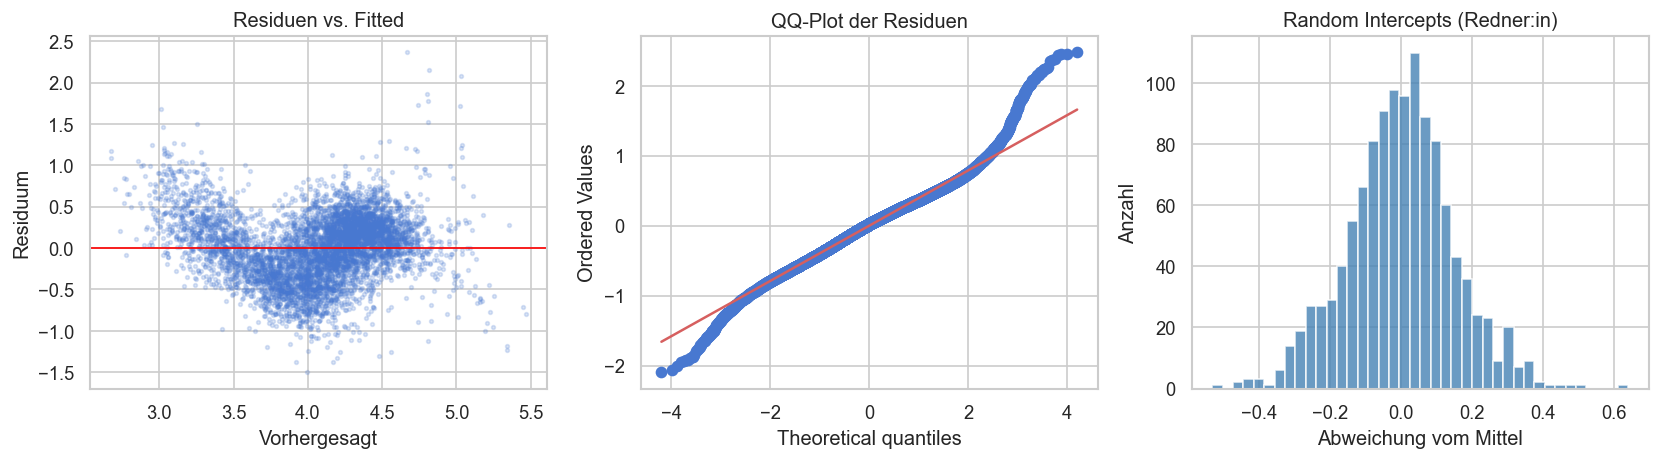

Residuen: Schiefe=0.04, Exzess-Kurtosis=1.23 (0/0 = normal)
AfD d mit quadratischer Längenkontrolle = +0.266 (vs. +0.219 linear) ⇒ stabil
Leave-Top-3-Redner:innen-out (Wolfgang Kubicki, Claudia Roth, Petra Pau): AfD d = +0.216 (vs. +0.219 im Hauptmodell) ⇒ stabil


In [15]:
# ---  Residual- & Annahmediagnostik ---
from scipy import stats
fitted = np.asarray(m2.fittedvalues); resid = np.asarray(m2.resid)
re_vals = np.array([float(v.iloc[0]) for v in m2.random_effects.values()])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
idx = np.random.choice(len(resid), min(6000, len(resid)), replace=False)   # Scatter-Subsample
axes[0].scatter(fitted[idx], resid[idx], s=5, alpha=0.2)
axes[0].axhline(0, color="red", lw=1)
axes[0].set(title="Residuen vs. Fitted", xlabel="Vorhergesagt", ylabel="Residuum")
stats.probplot(resid, dist="norm", plot=axes[1]); axes[1].set_title("QQ-Plot der Residuen")
axes[2].hist(re_vals, bins=40, color="steelblue", alpha=0.8)
axes[2].set(title="Random Intercepts (Redner:in)", xlabel="Abweichung vom Mittel", ylabel="Anzahl")
plt.tight_layout(); plt.savefig(FIG/"diagnostics.png"); plt.show()
print(f"Residuen: Schiefe={stats.skew(resid):.2f}, Exzess-Kurtosis={stats.kurtosis(resid):.2f} "
      f"(0/0 = normal)")

# --- Robustheit: nichtlineare Längenkontrolle (Quadratterm) gegen die Residuenkrümmung ---
m2_quad = fit_lmm(f"surprisal_z ~ is_afd + {COVARS} + I(log_n_tokens**2)", analysis)
d_quad = float(m2_quad.fe_params["is_afd"]); RESULTS["afd_d_quad_length"] = d_quad
print(f"AfD d mit quadratischer Längenkontrolle = {d_quad:+.3f} (vs. {d_afd:+.3f} linear) ⇒ "
      f"{'stabil' if abs(d_quad - d_afd) < 0.05 else 'sensitiv'}")

# --- Einflussreiche Vielredner:innen: M2 ohne Top-3-Redner:innen erneut schätzen ---
top3 = analysis["name"].value_counts().head(3).index.tolist()
m2_loo = fit_lmm(f"surprisal_z ~ is_afd + {COVARS}", analysis[~analysis["name"].isin(top3)])
print(f"Leave-Top-3-Redner:innen-out ({', '.join(top3)}): "
      f"AfD d = {m2_loo.fe_params['is_afd']:+.3f} (vs. {d_afd:+.3f} im Hauptmodell) ⇒ "
      f"{'stabil' if abs(m2_loo.fe_params['is_afd']-d_afd) < 0.05 else 'sensitiv'}")

## **Block G:** Ergebnissicherung

Das zur Laufzeit gefüllte `RESULTS`-Dictionary wird als finaler Schritt zur einfachen Kontrolle gespeichert.

In [18]:
(ROOT/"output"/"results.json").write_text(json.dumps(RESULTS, indent=2, ensure_ascii=False))

1199